In [1]:
!wget https://opig.stats.ox.ac.uk/webapps/ngsdb/unpaired/Gupta_2017/csv/SRR4431787_1_Heavy_IGHG.csv.gz


--2026-03-13 23:10:40--  https://opig.stats.ox.ac.uk/webapps/ngsdb/unpaired/Gupta_2017/csv/SRR4431787_1_Heavy_IGHG.csv.gz
Resolving opig.stats.ox.ac.uk (opig.stats.ox.ac.uk)... 163.1.32.59
Connecting to opig.stats.ox.ac.uk (opig.stats.ox.ac.uk)|163.1.32.59|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11080112 (11M) [application/x-gzip]
Saving to: ‘SRR4431787_1_Heavy_IGHG.csv.gz.2’

SRR4431787_1_Heavy_ 100%[===================>]  10.57M  6.80MB/s    in 1.6s    

2026-03-13 23:10:43 (6.80 MB/s) - ‘SRR4431787_1_Heavy_IGHG.csv.gz.2’ saved [11080112/11080112]



In [2]:
file_path = '/content/SRR4431787_1_Heavy_IGHG.csv.gz'


In [3]:
!pip install fair-esm
import torch
import esm

In [4]:
# =========================
# 1️⃣ Imports
# =========================
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import esm
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [5]:
# =========================
# 2️⃣ Load OAS CSV
# =========================
# Replace with your file path
df = pd.read_csv(file_path, skiprows = 1)
df = df[['sequence_alignment_aa']]  # only keep sequence column

# Train/val/test split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)


In [6]:
# =========================
# 3️⃣ PyTorch Dataset
# =========================
class ESM2Dataset(Dataset):
    def __init__(self, dataframe, seq_col="sequence_alignment_aa"):
        self.names = dataframe.index.tolist()
        self.sequences = dataframe[seq_col].tolist()

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (self.names[idx], self.sequences[idx])  # tuple: (name, sequence)

train_dataset = ESM2Dataset(train_df)
val_dataset   = ESM2Dataset(val_df)
test_dataset  = ESM2Dataset(test_df)



In [7]:
# =========================
# 4️⃣ Load ESM-2 Model
# =========================
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)


cuda


In [8]:
# =========================
# 5️⃣ Optional MLM masking function
# =========================
def mask_sequence(sequence, mask_token="<mask>", mlm_prob=0.15):
    # Convert sequence to list of chars
    seq_chars = list(sequence)
    for i in range(len(seq_chars)):
        if random.random() < mlm_prob:
            seq_chars[i] = mask_token
    return "".join(seq_chars)


In [9]:
# =========================
# 6️⃣ Collate function for DataLoader
# =========================
def esm_collate_fn(batch, mlm=False, mlm_prob=0.15):
    # batch: list of (name, sequence)
    names, sequences = zip(*batch)

    if mlm:
        sequences = [mask_sequence(seq, mlm_prob=mlm_prob) for seq in sequences]

    batch_labels, batch_strs, batch_tokens = batch_converter(list(zip(names, sequences)))
    return batch_labels, batch_strs, batch_tokens


In [10]:
# =========================
# 7️⃣ DataLoaders
# =========================
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,
                          collate_fn=lambda x: esm_collate_fn(x, mlm=True, mlm_prob=0.15))
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False,
                          collate_fn=lambda x: esm_collate_fn(x, mlm=False))
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False,
                          collate_fn=lambda x: esm_collate_fn(x, mlm=False))



In [11]:
train_dataset[0]

(6335,
 'QAQLVQSGGGVVQPGTSLRLCCAASGLPLSDYGMHWVRQAPGKGLEWMAVMSDDGSNQWYADSVRGRFTISRDNSKNTLFLQMNSLRADDTAVYYCAKGGRHNWNYDGDYWGQGTPVTVSS')

In [12]:
next(iter(train_loader))

([13046, 1390, 453, 3667, 4743, 9230, 12361, 6749],
 ['QVQLVQ<mask>GGG<mask>VLPGSSL<mask>LSCAPS<mask><mask>IFS<mask>YGMHLVRQVPGKGL<mask>W<mask>AVMSDDGSNQ<mask>Y<mask>DSVRGRFTI<mask>RDYSENTLILQ<mask>NSLRRD<mask>TAGYYCAK<mask>GR<mask>NWNFDGDYWGQ<mask>TLVTVT<mask>',
  '<mask><mask>QL<mask>ESG<mask>GLVKPSETLSLTCTVSGDSIS<mask><mask>YWSWIRQPPGTGLEW<mask>GHVY<mask>TGNTK<mask>NPSLK<mask>RVTMS<mask>DMSKNEVSLKLT<mask>VTAADTAVY<mask>C<mask>ST<mask>L<mask>AT<mask>DDYY<mask>EYMDV<mask>GKGTTVTVSS',
  '<mask>LVESGGGLVQPGQSLRLSCAASGF<mask>FDD<mask>A<mask>NWVRQVPG<mask><mask>LEWVAGLTW<mask><mask><mask>KIAY<mask>DSVQGRFTI<mask>RDNARKSL<mask>L<mask>MNSLSAED<mask>ALYYCAKARFPF<mask>HYESSGYDLG<mask>ALDVWGQ<mask>TMVTVSS',
  'Q<mask>QLVGSGGGLVKPGGS<mask>RV<mask>CEAS<mask>FTFSDY<mask>MSWVR<mask><mask>PGK<mask>LEW<mask><mask>YITSTGGSVY<mask>ADSVKG<mask>FTISRDN<mask>KNSLSLQMNDLRAEDT<mask>V<mask>YCSA<mask>PE<mask>GF<mask>YG<mask><mask>V<mask>GQGTTVT<mask>SS',
  'EVQL<mask>ESGGG<mask><mask>QPGGSMRLSC<mask>ASGFT<ma

Even though we have train/test/validate, the purpose of this notebook is to just make inference. In the other notebooks, we will show how to fine-tune a model.

In [13]:
# =========================
# 8️⃣ Extract embeddings
# =========================
sequence_representations = []

for batch_labels, batch_strs, batch_tokens in test_loader:
    batch_tokens = batch_tokens.to(device)
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33], return_contacts=True)
        token_representations = results["representations"][33]
        batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

        for i, tokens_len in enumerate(batch_lens):
            seq_repr = token_representations[i, 1 : tokens_len - 1].mean(0)
            sequence_representations.append(seq_repr.cpu())  # move to CPU if needed


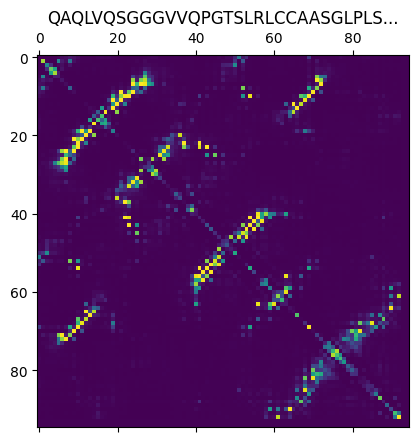

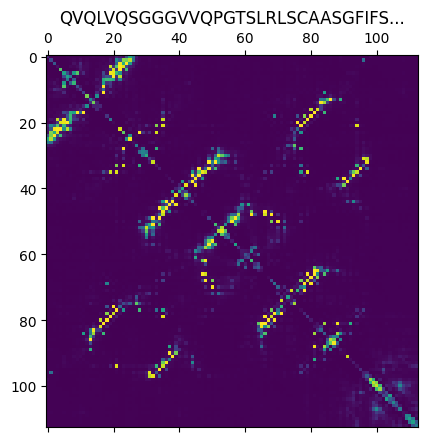

Number of sequence embeddings: 1914
Embedding dimension: torch.Size([1280])


In [14]:
# =========================
# 9️⃣ Optional: Visualize attention maps
# =========================
for (_, seq), tokens_len, attention_contacts in zip(train_dataset, batch_lens, results["contacts"]):

    tokens_len = tokens_len.item()   # convert tensor → int
    contacts = attention_contacts.cpu()

    plt.matshow(contacts[:tokens_len, :tokens_len])
    plt.title(seq[:30] + "...")
    plt.show()

# =========================
# ✅ sequence_representations now contains per-sequence embeddings
# =========================
print("Number of sequence embeddings:", len(sequence_representations))
print("Embedding dimension:", sequence_representations[0].shape)